In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

df = pd.read_csv('data/data.csv')
df.head(5)

,sno,age,gender,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,male,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,yes
1,1,37,male,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,yes
2,2,41,female,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,yes
3,3,56,male,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,yes
4,4,57,female,0,NaN,354.0,0,1,163.0,1,0.6,2,0,2,yes


In [29]:
df['gender']=pd.factorize(df['gender'])[0]
df.isna().sum()

sno         0
age         0
gender      0
cp          0
trestbps    4
chol        1
fbs         0
restecg     0
thalach     5
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [30]:
cleaned_df=df.dropna()
cleaned_df.shape[0]

293

In [31]:
x = cleaned_df.drop("target", axis=1)
y = cleaned_df["target"]

np.random.seed(42)

# Split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [32]:
from sklearn.model_selection import RandomizedSearchCV

log_reg_grid = {"C": np.logspace(-4, 4, 20),
                "solver": ["liblinear"]}

rs_log_reg = RandomizedSearchCV(LogisticRegression(),
                                param_distributions=log_reg_grid,
                                cv=5,
                                n_iter=20,
                                verbose=True)
rs_log_reg.fit(x_train, y_train)
rs_log_reg.best_params_

Fitting 5 folds for each of 20 candidates, totalling 100 fits


{'solver': 'liblinear', 'C': np.float64(0.615848211066026)}

In [33]:
rs_log_reg.score(x_test, y_test)

0.9830508474576272

In [34]:
x_test.iloc[0]

sno          87.0
age          46.0
gender        0.0
cp            1.0
trestbps    101.0
chol        197.0
fbs           1.0
restecg       1.0
thalach     156.0
exang         0.0
oldpeak       0.0
slope         2.0
ca            0.0
thal          3.0
Name: 87, dtype: float64

In [35]:
rs_log_reg.predict(x_test.iloc[[0]])

array(['yes'], dtype=object)

In [36]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [37]:
import shap
import pandas as pd

# Use the trained Logistic Regression model
model = rs_log_reg.best_estimator_

# Create SHAP explainer
explainer = shap.LinearExplainer(model, x_train)

# Calculate SHAP values on the test set
shap_values = explainer(x_test)

print("SHAP analysis completed.")
print("Test samples:", x_test.shape[0])
print("Features:", x_test.shape[1])

Background dataset has 234 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=234 when initializing the masker.


SHAP analysis completed.
Test samples: 59
Features: 14


In [38]:
# Calculate mean absolute SHAP value for each feature
shap_importance = pd.DataFrame({
    "feature": x_test.columns,
    "mean_abs_shap": abs(shap_values.values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "mean_abs_shap",
    ascending=True
).reset_index(drop=True)

print("Feature impact ranking (least → most):")
print(shap_importance.to_string(index=False))

Feature impact ranking (least → most):
 feature  mean_abs_shap
   exang       0.006960
    thal       0.007379
     fbs       0.011561
  gender       0.011657
      ca       0.139891
   slope       0.248179
 restecg       0.250865
      cp       0.360391
 oldpeak       1.035425
    chol       1.090068
     age       2.110840
trestbps       2.193408
 thalach       3.665173
     sno      28.667377


/var/tmp/ipykernel_38799/3681701658.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


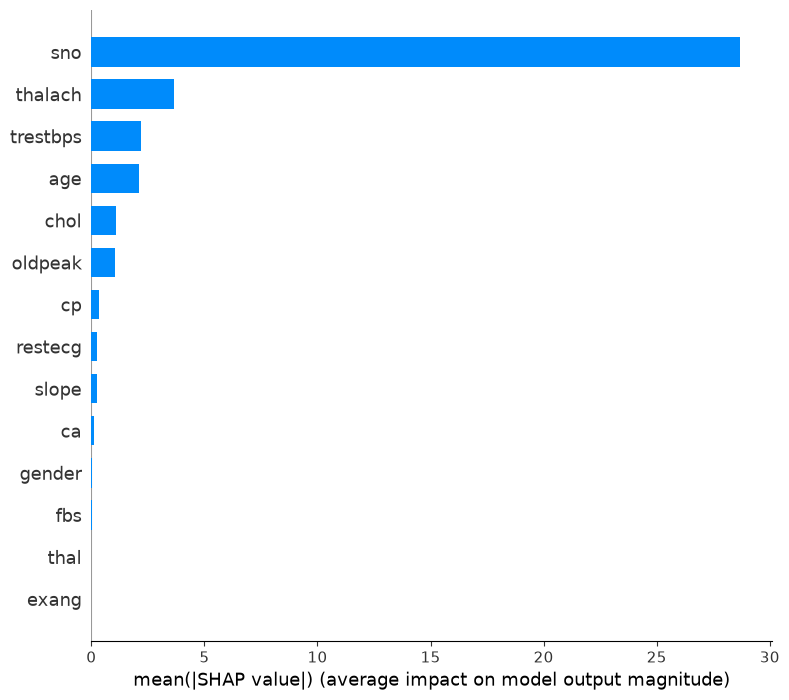

In [39]:
shap.summary_plot(
    shap_values,
    x_test,
    plot_type="bar"
)

In [40]:
%pip install fairlearn

Note: you may need to restart the kernel to use updated packages.


# Deliverable 3 — Fairness Analysis

This section evaluates the fairness of the heart disease prediction model using Fairlearn.

The sensitive attribute used for fairness analysis is **age**, as specified in the OPPE-2 problem statement.

We evaluate the model's prediction behavior across different age groups using fairness metrics such as selection rate, true positive rate, and false positive rate.

In [41]:
from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    true_positive_rate,
    false_positive_rate
)

print("Fairlearn imported successfully.")

Fairlearn imported successfully.


In [42]:
# Generate predictions on the test set
y_pred = model.predict(x_test)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))

Predictions generated successfully.
Number of predictions: 59


In [43]:
# Create age groups for fairness analysis
age_groups = pd.cut(
    x_test["age"],
    bins=[0, 40, 50, 60, 100],
    labels=["≤40", "41–50", "51–60", ">60"]
)

print("Age groups created successfully.")
print(age_groups.value_counts().sort_index())

Age groups created successfully.
age
≤40       5
41–50    17
51–60    23
>60      14
Name: count, dtype: int64


In [44]:
# Evaluate fairness across age groups
metric_frame = MetricFrame(
    metrics={
        "selection_rate": lambda y_true, y_pred: selection_rate(
            y_true, y_pred, pos_label="yes"
        ),
        "true_positive_rate": lambda y_true, y_pred: true_positive_rate(
            y_true, y_pred, pos_label="yes"
        ),
        "false_positive_rate": lambda y_true, y_pred: false_positive_rate(
            y_true, y_pred, pos_label="yes"
        )
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=age_groups
)

print("Fairness metrics by age group:")
print(metric_frame.by_group)

Fairness metrics by age group:
       selection_rate  true_positive_rate  false_positive_rate
age                                                           
41–50        0.647059                 1.0                  0.0
51–60        0.608696                 1.0                  0.1
>60          0.428571                 1.0                  0.0
≤40          0.800000                 1.0                  0.0


# Fairness Analysis Results

Fairness was evaluated using **age** as the sensitive attribute.

The test data was divided into four age groups: ≤40, 41–50, 51–60, and >60.

The Fairlearn results show a selection rate difference of approximately **0.3714** across the age groups. The true positive rate difference is **0.0**, meaning the true positive rates were equal across all groups. The false positive rate difference is **0.10**, with the 51–60 age group having a false positive rate of 0.10 while the other groups had a false positive rate of 0.0.

The results indicate some disparity in selection rates across age groups and a smaller disparity in false-positive behavior, while the true positive rates are equal in this test set.

These results should be interpreted in the context of the relatively small number of samples in each age group.

In [45]:
# Calculate fairness disparities across age groups
by_group = metric_frame.by_group

selection_rate_difference = (
    by_group["selection_rate"].max() - by_group["selection_rate"].min()
)

true_positive_rate_difference = (
    by_group["true_positive_rate"].max() - by_group["true_positive_rate"].min()
)

false_positive_rate_difference = (
    by_group["false_positive_rate"].max() - by_group["false_positive_rate"].min()
)

print("Selection rate difference:", selection_rate_difference)
print("True positive rate difference:", true_positive_rate_difference)
print("False positive rate difference:", false_positive_rate_difference)

Selection rate difference: 0.3714285714285715
True positive rate difference: 0.0
False positive rate difference: 0.1


## Fairness Conclusion

Using **age** as the sensitive attribute, the model was evaluated across four age groups.

The selection rate difference is **0.3714**, the true positive rate difference is **0.0**, and the false positive rate difference is **0.10**.

This indicates that the model shows some disparity in selection rates across age groups and a smaller disparity in false-positive behavior, while the true positive rates are equal in this test set.

These results are based on the available test samples and should be interpreted with the relatively small size of each age group in mind.

# Deliverable 4 — Dockerized API, GKE Deployment, Autoscaling and CI/CD

This section prepares the trained heart disease prediction model for production deployment.

The model will be exposed through a REST API, containerized using Docker, deployed to Google Kubernetes Engine (GKE), configured with Kubernetes autoscaling, and integrated with GitHub Actions for CI/CD.

In [46]:
import joblib
import os

# Save the trained model
model_path = "heart_disease_model.pkl"
joblib.dump(model, model_path)

print(f"Model saved to: {model_path}")
print(f"File exists: {os.path.exists(model_path)}")

Model saved to: heart_disease_model.pkl
File exists: True
